In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bank_final.csv")
df.head()

,housing,loan,job_stability_score,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,...,income_concentration,event_dependence_score,bill_payment_score,upi_txn_count,ecommerce_spend_ratio,location_stability,merchant_rating,education_score,marital_score,default
0,1,0,0.80,0,1,0,0,1,0,0,...,0.363267,0.389186,0.134658,281,0.092243,0.221170,4.085765,0.4,0.6,1
1,0,0,0.80,0,1,0,0,1,0,0,...,0.115537,0.048150,0.317840,144,0.700937,0.307802,1.850372,0.4,0.6,0
2,1,0,0.85,0,1,0,0,1,0,0,...,0.309224,0.311414,0.593508,166,0.323326,0.677482,2.907946,0.4,0.6,0
3,1,0,0.65,0,1,0,0,1,0,0,...,0.159737,0.280073,0.544591,227,0.246584,0.066027,1.372812,0.4,0.6,0
4,0,0,0.80,0,1,0,0,0,1,0,...,0.259727,0.132701,0.597934,58,0.246629,0.861599,3.436350,0.7,0.6,0


In [3]:
# Drop redundant column if present
if "annual_income" in df.columns:
    df.drop(columns=["annual_income"], inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   housing                 11162 non-null  int64  
 1   loan                    11162 non-null  int64  
 2   job_stability_score     11162 non-null  float64
 3   marital_divorced        11162 non-null  int64  
 4   marital_married         11162 non-null  int64  
 5   marital_single          11162 non-null  int64  
 6   education_primary       11162 non-null  int64  
 7   education_secondary     11162 non-null  int64  
 8   education_tertiary      11162 non-null  int64  
 9   education_unknown       11162 non-null  int64  
 10  balance_norm            11162 non-null  float64
 11  monthly_income_avg      11162 non-null  int64  
 12  income_variance         11162 non-null  float64
 13  seasonality_score       11162 non-null  float64
 14  income_concentration    11162 non-null

In [4]:
X = df.drop("default", axis=1)
y = df["default"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9122257053291536
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1814
           1       0.72      0.88      0.79       419

    accuracy                           0.91      2233
   macro avg       0.84      0.90      0.87      2233
weighted avg       0.92      0.91      0.92      2233



In [8]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight
)

lgbm.fit(X_train, y_train)

lgb_pred = lgbm.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, lgb_pred))
print(classification_report(y_test, lgb_pred))

[LightGBM] [Info] Number of positive: 1688, number of negative: 7241
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2832
[LightGBM] [Info] Number of data points in the train set: 8929, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.189047 -> initscore=-1.456215
[LightGBM] [Info] Start training from score -1.456215
LightGBM Accuracy: 0.9762651141961487
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1814
           1       0.93      0.95      0.94       419

    accuracy                           0.98      2233
   macro avg       0.96      0.96      0.96      2233
weighted avg       0.98      0.98      0.98      2233



In [9]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9758172861621137
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1814
           1       0.89      0.99      0.94       419

    accuracy                           0.98      2233
   macro avg       0.95      0.98      0.96      2233
weighted avg       0.98      0.98      0.98      2233



In [10]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

In [11]:
ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("lgbm", lgbm),
        ("lr", lr_pipeline)
    ],
    voting="soft"   # probability-based voting
)

ensemble.fit(X_train, y_train)

ens_pred = ensemble.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ens_pred))
print(classification_report(y_test, ens_pred))

[LightGBM] [Info] Number of positive: 1688, number of negative: 7241
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000288 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2832
[LightGBM] [Info] Number of data points in the train set: 8929, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.189047 -> initscore=-1.456215
[LightGBM] [Info] Start training from score -1.456215
Ensemble Accuracy: 0.9829825347066726
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1814
           1       0.95      0.96      0.95       419

    accuracy                           0.98      2233
   macro avg       0.97      0.97      0.97      2233
weighted avg       0.98      0.98      0.98      2233



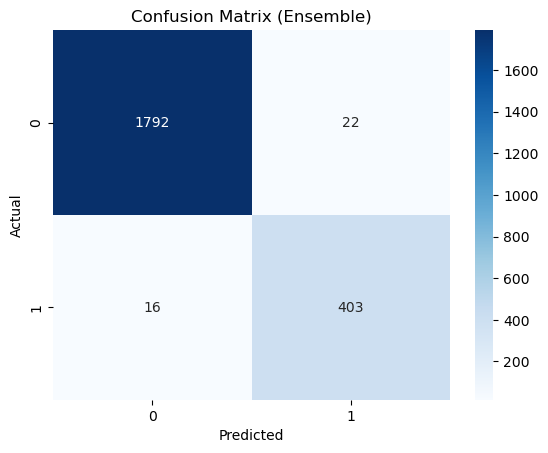

In [12]:
import seaborn as sns

cm = confusion_matrix(y_test, ens_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Ensemble)")
plt.show()

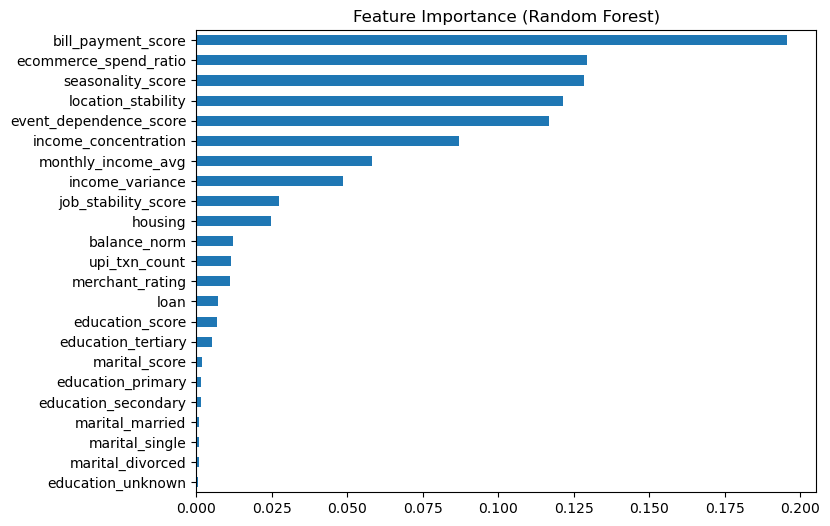

In [13]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(ensemble, X, y, cv=5)
print(scores)
print("Mean:", scores.mean())

[LightGBM] [Info] Number of positive: 1685, number of negative: 7244
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2831
[LightGBM] [Info] Number of data points in the train set: 8929, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.188711 -> initscore=-1.458408
[LightGBM] [Info] Start training from score -1.458408
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1685, number of negative: 7244
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2830
[LightGBM] [Info] Number of data points in the train set: 8929, number of used features: 23
[LightGBM] [I